# Cell cycle analysis in Capolupo Human Dermal Fibroblasts

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import random
import seaborn as sns
import scanpy as sc
import scanpy.external as sce
import scipy.stats as ss
from chunter.data_utils import download_data

from pathlib import Path
from ripser import ripser
from scipy.spatial import distance
from tqdm import tqdm

import chunter as chnt
import ringity as rng

RANDOM_STATE = 240209

# Download data

Download the example data that is required to run this notebook. It's three files that will be copied into the `data/` subfolder. Size is approximately 140MB.

In [2]:
download_data(
    url="https://zenodo.org/records/12517650/files/capolupo_fibroblasts_cycling.h5ad.gz",
    out_path="data/",
    uncompress=True,
)
download_data(
    url="https://raw.githubusercontent.com/kmaggs/cocycle-hunter/refs/heads/main/examples/Capolupo/data/regev_lab_cell_cycle_genes.txt",
    out_path="data/",
)
download_data(
    url="https://raw.githubusercontent.com/kmaggs/cocycle-hunter/ea5a13bfe1cbd9d088475df2fe1df419f7ac77cb/examples/Capolupo/data/velocycle_small_cc_genes.csv",
    out_path="data/",
)

'data/velocycle_small_cc_genes.csv'

# Loading and pre-processing

In the first section we will use the same processing as the Lederer VeloCycle paper. 

In [3]:
# load the adata object from a file
adata = sc.read_h5ad("data/capolupo_fibroblasts_cycling.h5ad")

In [4]:
adata.obs["n_counts"] = adata.X.sum(axis=1)
adata.obs["total_log1p_counts"] = np.log(adata.obs["n_counts"] + 1)

In [5]:
sc.pp.filter_genes(adata, min_cells=int((adata.n_obs) * 0.10))

In [6]:
# this is from the Lederer paper
adata = adata[:, (adata.layers["unspliced"].toarray().mean(0) > 0.1)].copy()
adata = adata[:, adata.layers["spliced"].toarray().mean(0) > 0.3].copy()

In [7]:
# Apply standard normalization
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)

# Log transform the data and scale
sc.pp.log1p(adata)
# scale data
# sc.pp.scale(adata)

# Diffusion and filtering for highly variable genes
# sce.pp.magic(adata, knn=4, t=1, random_state=RANDOM_STATE, n_jobs=4)

/var/folders/q4/2fqjcfrs3k36ykkvbcqd0bcc0000gp/T/ipykernel_89714/3816533813.py:4: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:589: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


# Cell cycle scoring

In [8]:
cell_cycle_genes = [x.strip() for x in open("data/regev_lab_cell_cycle_genes.txt")]

# Separate out the components of the cell cycle genes
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

# score cells by cell cycle phase
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

       'EXO1', 'BLM', 'CASP8AP2', 'E2F8'],
      dtype='object')


In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)

# Cell cycle analysis

In [10]:
# read csv with Data/Dotto/velocycle_small_cc_genes.csv
velocycle_small_cc_genes = pd.read_csv("data/velocycle_small_cc_genes.csv")

# convert velocycle_small_cc_genes to a list
velocycle_small_cc_genes = velocycle_small_cc_genes["0"].tolist()

# subset adata.var_names to only include the genes in velocycle_small_cc_genes
adata_cc = adata[:, adata.var_names.isin(velocycle_small_cc_genes)].copy()

In [11]:
adata_cc

AnnData object with n_obs × n_vars = 1222 × 79
    obs: 'n_counts', 'total_log1p_counts', 'n_genes', 'S_score', 'G2M_score', 'phase'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'spliced', 'unspliced'

## Spliced vs Unspliced

In [20]:
cc_splicing = adata_cc.copy()

spliced_var_names = [x + "_spliced" for x in adata_cc.var_names]
unspliced_var_names = [x + "_unspliced" for x in adata_cc.var_names]

var_names = spliced_var_names + unspliced_var_names

# turn spliced and unspliced into arrays
spliced = adata_cc.layers["spliced"]

unspliced = adata_cc.layers["unspliced"]

# convert to non sparse arrays
spliced = spliced.toarray()
unspliced = unspliced.toarray()

# concatenate the spliced and unspliced var names along axis 1
con = np.concatenate([spliced, unspliced], axis=1)

# change to float
con = con.astype("float32")

In [21]:
# create a new adata object with X = con, var_names and obs_names
adata = sc.AnnData(X=con, obs=adata_cc.obs)

adata.var_names = var_names

In [22]:
sc.pp.filter_genes(adata, min_cells=5)
sc.pp.filter_cells(adata, min_genes=20)
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)

# Log transform the data and scale
sc.pp.log1p(adata)

/var/folders/q4/2fqjcfrs3k36ykkvbcqd0bcc0000gp/T/ipykernel_89714/2636385680.py:3: FutureWarning:

Use sc.pp.normalize_total instead

/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:589: FutureWarning:

Use sc.pp.normalize_total instead



In [51]:
adata.X

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [5.388997 , 4.41575  , 0.       , ..., 3.341021 , 0.       ,
        5.102836 ],
       [4.1950865, 4.4789944, 4.1950865, ..., 0.       , 0.       ,
        3.797128 ],
       ...,
       [4.062903 , 4.062903 , 4.062903 , ..., 0.       , 0.       ,
        4.062903 ],
       [6.163175 , 5.2500377, 0.       , ..., 0.       , 0.       ,
        5.2500377],
       [5.343928 , 0.       , 0.       , ..., 3.575773 , 3.575773 ,
        4.6555467]], shape=(1154, 158), dtype=float32)

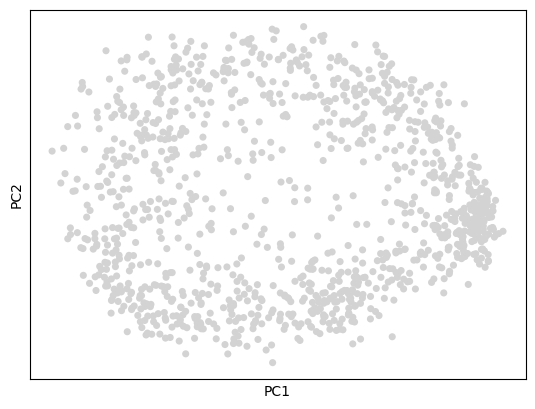

In [24]:
# run pca
sc.tl.pca(adata, n_comps=30, svd_solver="arpack", random_state=RANDOM_STATE)

# plot pca
sc.pl.pca(adata)

In [25]:
chnt.scatter3D(adata)

### Stochastic Cell Trajectories

In [37]:
from itertools import product
import ot   # discrete optimal transport
from sklearn.metrics import pairwise_distances

In [38]:
# compute dissimilarity matrix
# use Euclidean distance in PCA with pca_comp
def get_D(cell_data, pca_comp=[0,1]):

    cell_proj = cell_data.obsm["X_pca"][:, pca_comp]    # first two coordinates in PCA

    num_cells = cell_proj.shape[0]
    D = np.zeros((num_cells, num_cells))    # dissimilarity matrix
    for i,j in product(range(num_cells), range(num_cells)):
        D[i,j] = (np.linalg.norm(cell_proj[i] - cell_proj[j]))**2
        
    return D


# measure
# for now, this is just uniform
# change this to density sensitive measure later
def mu(x, cell_data):
    return 1 / cell_data.shape[0]

In [45]:
def r(x, cell_data):
    return cell_data.layers["unspliced"][x,0]   # for now, just take the first gene

def s(x, cell_data):
    return cell_data.layers["spliced"][x,0]

In [49]:
svals

[np.uint32(0),
 np.uint32(3),
 np.uint32(4),
 np.uint32(1),
 np.uint32(5),
 np.uint32(7),
 np.uint32(13),
 np.uint32(5),
 np.uint32(5),
 np.uint32(1),
 np.uint32(3),
 np.uint32(4),
 np.uint32(1),
 np.uint32(11),
 np.uint32(2),
 np.uint32(0),
 np.uint32(4),
 np.uint32(7),
 np.uint32(4),
 np.uint32(2),
 np.uint32(7),
 np.uint32(8),
 np.uint32(2),
 np.uint32(7),
 np.uint32(1),
 np.uint32(2),
 np.uint32(4),
 np.uint32(2),
 np.uint32(0),
 np.uint32(1),
 np.uint32(7),
 np.uint32(2),
 np.uint32(10),
 np.uint32(3),
 np.uint32(8),
 np.uint32(1),
 np.uint32(0),
 np.uint32(1),
 np.uint32(3),
 np.uint32(5),
 np.uint32(4),
 np.uint32(2),
 np.uint32(4),
 np.uint32(2),
 np.uint32(3),
 np.uint32(12),
 np.uint32(2),
 np.uint32(1),
 np.uint32(8),
 np.uint32(0),
 np.uint32(11),
 np.uint32(3),
 np.uint32(1),
 np.uint32(11),
 np.uint32(9),
 np.uint32(3),
 np.uint32(11),
 np.uint32(1),
 np.uint32(0),
 np.uint32(3),
 np.uint32(3),
 np.uint32(3),
 np.uint32(3),
 np.uint32(2),
 np.uint32(0),
 np.uint32(0),
 np

In [44]:
cell_data = adata_cc.copy()
num_cells = cell_data.shape[0]
D = get_D(cell_data)

rvals = [r(x, cell_data) for x in range(num_cells)]
svals = [s(x, cell_data) for x in range(num_cells)]

r_bar = sum([rvals[x]*mu(x, cell_data) for x in range(num_cells)])

def get_C(alpha, epsilon):
    return D + alpha * np.transpose(np.outer(svals, rvals - r_bar*np.ones(num_cells))) - epsilon * np.ones((D.shape[0], D.shape[0]))

C = get_C(1,1)


In [53]:
m = np.array([mu(x, cell_data) for x in range(num_cells)])
transport = ot.sinkhorn(m, m, get_C(10e+1, 1e+0), 1e+0)
transport

/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/ot/backend.py:1203: RuntimeWarning:

overflow encountered in exp

/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:623: RuntimeWarning:

overflow encountered in multiply

/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning:




array([[1.90034356e-006, 6.53976592e-001, 9.77743427e-026, ...,
        8.16274050e-026, 1.89524568e-001, 2.47618825e-019],
       [9.37813999e-009, 1.32518837e+002, 1.80457923e-024, ...,
        2.64967512e-022, 1.87588963e+003, 9.06563261e-012],
       [3.40641520e-036, 4.38423802e-027, 5.45455652e+004, ...,
        1.78706501e-005, 7.18256671e-015, 3.44579946e-025],
       ...,
       [1.98314358e-028, 4.48906908e-017, 1.24619454e+003, ...,
        7.82193051e-004, 2.75394293e-006, 8.20464847e-016],
       [6.60295279e-012, 4.55748714e+000, 7.18256671e-015, ...,
        3.94920287e-014, 5.45455652e+004, 4.96388254e-008],
       [2.47618825e-019, 1.22797119e+127, 5.16428360e+159, ...,
        9.07799627e+030, 7.43946288e+176, 1.90034356e-006]],
      shape=(1196, 1196))

In [57]:
rvals

[np.uint32(1),
 np.uint32(1),
 np.uint32(1),
 np.uint32(0),
 np.uint32(1),
 np.uint32(0),
 np.uint32(1),
 np.uint32(1),
 np.uint32(0),
 np.uint32(0),
 np.uint32(0),
 np.uint32(1),
 np.uint32(1),
 np.uint32(10),
 np.uint32(0),
 np.uint32(0),
 np.uint32(2),
 np.uint32(2),
 np.uint32(0),
 np.uint32(0),
 np.uint32(2),
 np.uint32(0),
 np.uint32(2),
 np.uint32(1),
 np.uint32(1),
 np.uint32(0),
 np.uint32(1),
 np.uint32(1),
 np.uint32(0),
 np.uint32(0),
 np.uint32(4),
 np.uint32(0),
 np.uint32(7),
 np.uint32(1),
 np.uint32(0),
 np.uint32(0),
 np.uint32(0),
 np.uint32(0),
 np.uint32(2),
 np.uint32(0),
 np.uint32(2),
 np.uint32(2),
 np.uint32(3),
 np.uint32(0),
 np.uint32(0),
 np.uint32(2),
 np.uint32(2),
 np.uint32(0),
 np.uint32(2),
 np.uint32(1),
 np.uint32(1),
 np.uint32(0),
 np.uint32(0),
 np.uint32(5),
 np.uint32(5),
 np.uint32(1),
 np.uint32(2),
 np.uint32(0),
 np.uint32(0),
 np.uint32(3),
 np.uint32(3),
 np.uint32(0),
 np.uint32(2),
 np.uint32(0),
 np.uint32(0),
 np.uint32(1),
 np.uint3

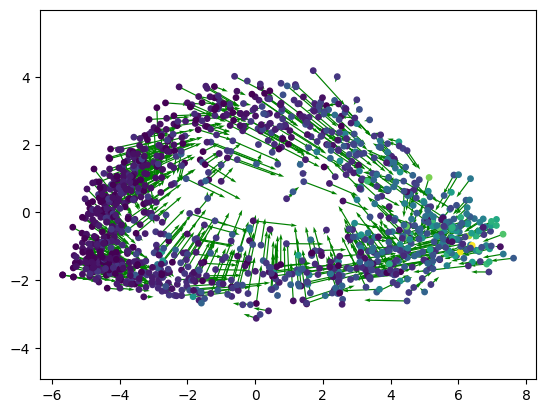

In [59]:
data = cell_data.obsm["X_pca"][:, [0,1]]    # spatial data

vecs = np.vstack([np.array(data[np.argmax(transport[i,:])]) - np.array(data[i]) for i in range(len(data))])
# avg_vec = np.vstack([sum(transport[i,j]*(np.array(data[j]) - np.array(data[i])) for j in range(len(data))) for i in range(len(data))])
data_np = np.vstack(data)

vecs2 = np.vstack([np.array(data_np[np.argsort(transport[i,:])[-2:][0]]) - np.array(data_np[i]) for i in range(len(data))])

x, y = data_np[:, 0], data_np[:, 1]
u, v = vecs[:, 0], vecs[:, 1]
w, z = vecs2[:, 0], vecs2[:, 1]
# u, v = avg_vec[:, 0], avg_vec[:, 1]

plt.quiver(x, y, u, v, angles="xy", scale_units="xy", scale=5, color="green")
# plt.quiver(x, y, w, z, angles="xy", scale_units="xy", scale=5, color="red")
plt.scatter(x, y, s=15, c =svals)
plt.axis("equal")
plt.show()

## Circle example

In [22]:
# compute dissimilarity matrix
# use Euclidean distance in PCA with pca_comp
def get_D(data):

    num = len(data)
    D = np.zeros((num, num))    # dissimilarity matrix
    for i,j in product(range(num), range(num)):
        D[i,j] = (np.linalg.norm(np.array(data[i]) - np.array(data[j])))**2
    return D
    
    # delta = np.unique(D.ravel())[1]
    # D_with_diag = np.array(D) + np.diag(delta*np.ones(num))     # add some small values to the diagonal
    # return D_with_diag

    # for i,j in product(range(num), range(num)):
    #      D[i,j] = np.abs(angles[i] - angles[j])

    # return D


# measure
# for now, this is just uniform
# change this to density sensitive measure later
def mu(x, data):
    return 1 / len(data)


def r(x, data):
    return data[x][1]  

def s(x, data):
    return data[x][0]

In [23]:
np.random.seed(42)

angles = np.random.uniform(0, 2*np.pi, size=50)
data = [[np.cos(theta), np.sin(theta)] for theta in angles]

D = get_D(data)

r_vals = [r(x, data) for x in range(len(data))]
s_vals = [s(x, data) for x in range(len(data))]

r_bar = sum([r_vals[x]*mu(x, data) for x in range(len(data))])

def get_C(alpha, epsilon):
    # return D - alpha*np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))

    cov = np.outer((np.array(r_vals) - r_bar*np.ones(len(data))), np.array(s_vals)) - np.diag((np.array(r_vals) - r_bar*np.ones(len(data)))*np.array(s_vals))
    return D + alpha*cov - epsilon*np.ones((len(data), len(data)))  # the last term accounts for the \sum_{i,j} P_{i,j} in the discrete entropy
    
    # cov = np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))
    # for i, j in np.ndindex(cov.shape):
    #     cov[i,j] = min(0, cov[i,j])
    # return D + alpha*cov

C = get_C(1, 1)
C

array([[-1.        ,  3.3280511 ,  2.18450947, ..., -0.79635019,
        -0.49509557,  0.49106823],
       [ 3.08090978, -1.        ,  0.65839377, ...,  3.24315578,
         3.06205774,  0.62850148],
       [ 3.04136549, -0.45952122, -1.        , ...,  1.63954894,
         1.28334678,  2.46622784],
       ...,
       [-0.04111924,  2.57069129,  0.55483049, ..., -1.        ,
        -0.72841408,  1.91909946],
       [ 0.35522908,  2.24893001,  0.25617221, ..., -0.5573132 ,
        -1.        ,  2.12635201],
       [-0.29595676,  1.55215282,  2.82388076, ...,  1.23801657,
         1.5378156 , -1.        ]], shape=(50, 50))

In [32]:
def plot_vectorfield(data, alpha, epsilon):
    
    m = np.array([mu(x, data) for x in range(len(data))])
    transport = ot.sinkhorn(m, m, get_C(alpha, epsilon), epsilon)

    vecs = np.vstack([np.array(data[np.argmax(transport[i,:])]) - np.array(data[i]) for i in range(len(data))])
    avg_vec = np.vstack([sum(transport[i,j]*(np.array(data[j]) - np.array(data[i])) for j in range(len(data))) for i in range(len(data))])
    data_np = np.vstack(data)

    vecs2 = np.vstack([np.array(data_np[np.argsort(transport[i,:])[-2:][0]]) - np.array(data_np[i]) for i in range(len(data))])

    x, y = data_np[:, 0], data_np[:, 1]
    u, v = avg_vec[:, 0], avg_vec[:, 1]
    w, z = vecs2[:, 0], vecs2[:, 1]
    # u, v = avg_vec[:, 0], avg_vec[:, 1]

    plt.quiver(x, y, u, v, angles="xy", scale_units="xy", scale=5, color="green")
    # plt.quiver(x, y, w, z, angles="xy", scale_units="xy", scale=5, color="red")
    plt.scatter(x, y, s=15)
    plt.axis("equal")
    plt.show()

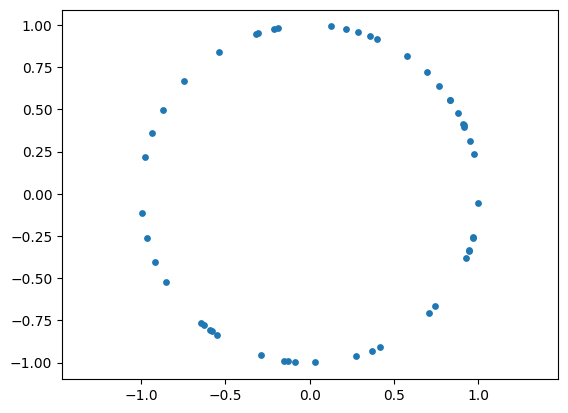

In [33]:
plot_vectorfield(data, 5*1e+0, 1e-1)

now try different measure with KDE

In [30]:
# new measure via kernel density estimation 

X = np.vstack(data)
D2 = pairwise_distances(X, squared=True)

sigma = 1e+0*np.median(np.sqrt(D2[D2>0]))          # heuristic bandwidth
K = np.exp(-D2/(2*sigma**2))
np.fill_diagonal(K, 0.0)

rho = K.sum(axis=1)
alpha = 1.0
eps = 1e-12
w = 1.0 / (rho + eps)**alpha
w = w / w.sum()

def mu(x, data):
    return w[x]

# need to run these computations again
np.random.seed(42)

angles = np.random.uniform(0, 2*np.pi, size=50)
data = [[np.sin(theta), np.cos(theta)] for theta in angles]

D = get_D(data)

r_vals = [r(x, data) for x in range(len(data))]
s_vals = [s(x, data) for x in range(len(data))]

r_bar = sum([r_vals[x]*mu(x, data) for x in range(len(data))])

def get_C(alpha, epsilon):
    # return D + alpha*np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))

    cov = np.outer((np.array(r_vals) - r_bar*np.ones(len(data))), np.array(s_vals)) - np.diag((np.array(r_vals) - r_bar*np.ones(len(data)))*np.array(s_vals))
    return D + alpha*cov - epsilon*np.ones((len(data), len(data)))

    # cov = np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))
    # for i, j in np.ndindex(cov.shape):
    #     cov[i,j] = min(0, cov[i,j])
    # return D - alpha*cov

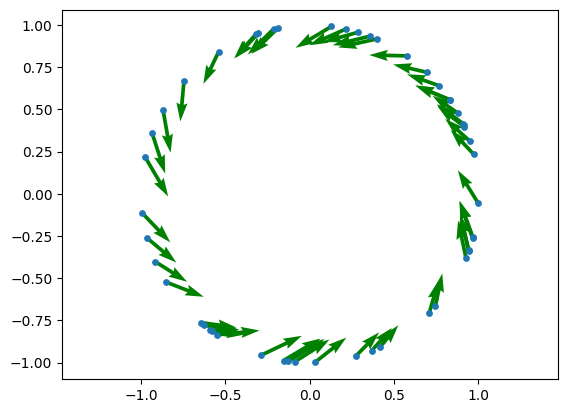

In [31]:
plot_vectorfield(data, 1e+1, 1e-0)

maybe this is slightly better? Some wrong arrows disappear here.

### Linear Constraints

In [24]:
import cvxpy as cp

m = np.array([mu(x, data) for x in range(len(data))])
n = D.shape[0]
P = cp.Variable((n, n), nonneg=True)
cov = np.outer((np.array(r_vals) - r_bar*np.ones(len(r_vals))), np.array(s_vals)) - np.diag((np.array(r_vals) - r_bar*np.ones(len(data)))*np.array(s_vals))

# delta = np.unique(D.ravel())[1]
# D_with_diag = np.array(D) + np.diag(delta*np.ones(n))

constraints = [
    cp.trace(cov.T @ P) <= 0,  # Cov constraint
    P @ np.ones(n) == m,    # OT constraints
    P.T @ np.ones(n) == m
]

eps = 1e+0
obj = cp.Minimize(cp.trace(D.T @ P) - eps * cp.sum(cp.entr(P)))
# obj = cp.Minimize(cp.sum(cp.multiply(D, P)))
# entr(x) = -x*log(x), so "-eps*sum(entr(P))" = eps*sum(P*log P) up to constants

prob = cp.Problem(obj, constraints)
prob.solve(solver="SCS")   # try also "ECOS"; MOSEK/GUROBI are faster if available

transport = P.value
prob.status

'optimal'

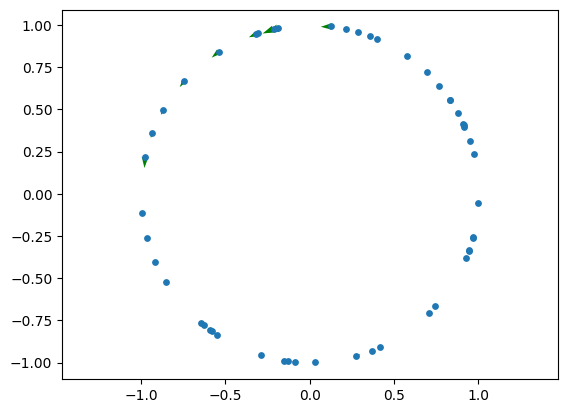

In [25]:
vecs = np.vstack([np.array(data[np.argmax(transport[i,:])]) - np.array(data[i]) for i in range(len(data))])
# avg_vec = np.vstack([sum(transport[i,j]*(np.array(data[j]) - np.array(data[i])) for j in range(len(data))) for i in range(len(data))])
data_np = np.vstack(data)

vecs2 = np.vstack([np.array(data_np[np.argsort(transport[i,:])[-2:][0]]) - np.array(data_np[i]) for i in range(len(data))])

x, y = data_np[:, 0], data_np[:, 1]
u, v = vecs[:, 0], vecs[:, 1]
w, z = vecs2[:, 0], vecs2[:, 1]
# u, v = avg_vec[:, 0], avg_vec[:, 1]

plt.quiver(x, y, u, v, angles="xy", scale_units="xy", scale=5, color="green")
# plt.quiver(x, y, w, z, angles="xy", scale_units="xy", scale=5, color="red")
plt.scatter(x, y, s=15)
plt.axis("equal")
plt.show()

In [618]:
transport

array([[0.00113975, 0.00017464, 0.00022585, ..., 0.00048272, 0.0004229 ,
        0.00032685],
       [0.00017464, 0.00124389, 0.00040252, ..., 0.000173  , 0.00018326,
        0.00027417],
       [0.00022585, 0.00040251, 0.00157146, ..., 0.00039844, 0.00046313,
        0.00016313],
       ...,
       [0.00048272, 0.000173  , 0.00039844, ..., 0.00114031, 0.00100224,
        0.00017668],
       [0.0004229 , 0.00018326, 0.00046313, ..., 0.00100223, 0.00117419,
        0.00016606],
       [0.00032685, 0.00027417, 0.00016313, ..., 0.00017669, 0.00016606,
        0.00084432]], shape=(50, 50))

# Torus

In [34]:
# compute dissimilarity matrix
# use squared Euclidean distance in PCA with pca_comp
def get_D(data):

    num = len(data)
    D = np.zeros((num, num))    # dissimilarity matrix
    for i,j in product(range(num), range(num)):
        D[i,j] = (np.linalg.norm(np.array(data[i]) - np.array(data[j])))**2
    return D
    

# measure
# for now, this is just uniform
# change this to density sensitive measure later
def mu(x, data):
    return 1 / len(data)


def r(x, data):
    return data[x][0]  

def s(x, data):
    return data[x][1]

In [35]:
np.random.seed(42)

big_radius = 1
small_radius = 0.5

num_samples = 200
samples_created = 0
data = []
while samples_created < num_samples:    # rejection sampling technique to get points on the torus
    phi = np.random.uniform(0, 2*np.pi)
    theta = np.random.uniform(0, 2*np.pi)
    u = np.random.uniform(0, 1)
    if u <= (big_radius + small_radius*np.cos(theta))/(big_radius + small_radius):
        data.append([(big_radius + small_radius*np.cos(theta))*np.cos(phi), (big_radius + small_radius*np.cos(theta))*np.sin(phi), small_radius*np.sin(theta)])
        samples_created += 1


D = get_D(data)
X = np.vstack(data)

sigma = 1e+0*np.median(np.sqrt(D[D>0]))          # heuristic bandwidth
K = np.exp(-D/(2*sigma**2))
np.fill_diagonal(K, 0.0)

rho = K.sum(axis=1)
alpha = 1.0
eps = 1e-12
w = 1.0 / (rho + eps)**alpha
w = w / w.sum()

def mu(x, data):    # this gives the heat kernel density measure
    return w[x]

r_vals = [r(x, data) for x in range(len(data))]
s_vals = [s(x, data) for x in range(len(data))]

r_bar = sum([r_vals[x]*mu(x, data) for x in range(len(data))])

def get_C(alpha, epsilon):
    # return D - alpha*np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))

    cov = np.outer((np.array(r_vals) - r_bar*np.ones(len(data))), np.array(s_vals)) - np.diag((np.array(r_vals) - r_bar*np.ones(len(data)))*np.array(s_vals))
    return D + alpha*cov - epsilon*np.ones((len(data), len(data)))  # the last term accounts for the \sum_{i,j} P_{i,j} in the discrete entropy
    
    # cov = np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))
    # for i, j in np.ndindex(cov.shape):
    #     cov[i,j] = min(0, cov[i,j])
    # return D + alpha*cov

C = get_C(1, 1)
C

array([[-1.        ,  3.31521948,  4.09566573, ...,  6.78177527,
         3.71298981,  3.51841564],
       [ 1.41070634, -1.        ,  5.82576232, ...,  4.8044368 ,
         6.07076548, -0.04902086],
       [ 5.88148379,  5.42463523, -1.        , ..., -0.15949013,
         0.15436312,  6.0053524 ],
       ...,
       [ 7.74030825,  3.55287283,  0.81218707, ..., -1.        ,
         1.28455111,  4.33888734],
       [ 5.85376356,  5.94622278, -0.17974417, ..., -0.05959135,
        -1.        ,  6.73635717],
       [ 1.36055684, -0.01259241,  6.42568083, ...,  5.73860488,
         6.83651952, -1.        ]], shape=(200, 200))

In [36]:
import plotly.graph_objects as go

def plot_vectorfield_3d(data, alpha, epsilon):

    m = np.array([mu(x, data) for x in range(len(data))])
    transport = ot.sinkhorn(m, m, get_C(alpha, epsilon), epsilon)
    vecs = np.vstack([np.array(data[np.argmax(transport[i,:])]) - np.array(data[i]) for i in range(len(data))])
    data_np = np.vstack(data)

    X = data_np
    V = vecs

    scale = 1.0  # adjust arrow length
    P0 = X
    P1 = X + scale * V

    # Build one trace containing many separate line segments using None separators
    xs, ys, zs = [], [], []
    for p0, p1 in zip(P0, P1):
        xs += [p0[0], p1[0], None]
        ys += [p0[1], p1[1], None]
        zs += [p0[2], p1[2], None]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(x=X[:,0], y=X[:,1], z=X[:,2],
                            mode="markers", marker=dict(size=3),
                            name="points"))

    fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs,
                            mode="lines", line=dict(width=4),
                            name="vectors"))

    fig.show()

In [37]:
plot_vectorfield_3d(data, 1e+1, 1e+0)

This works as expected. One observes the vector field going around the outer circle.

In [38]:
np.random.seed(42)

big_radius = 1
small_radius = 0.5

num_samples = 200
samples_created = 0
clifford_data = []
while samples_created < num_samples:    # rejection sampling technique to get points on the torus
    phi = np.random.uniform(0, 2*np.pi)
    theta = np.random.uniform(0, 2*np.pi)
    u = np.random.uniform(0, 1)
    if u <= (big_radius + small_radius*np.cos(theta))/(big_radius + small_radius):
        clifford_data.append([big_radius*np.cos(theta), big_radius*np.sin(theta), small_radius*np.cos(phi), small_radius*np.sin(phi)])
        samples_created += 1


D = get_D(clifford_data)
X = np.vstack(clifford_data)

sigma = 1e+0*np.median(np.sqrt(D[D>0]))          # heuristic bandwidth
K = np.exp(-D/(2*sigma**2))
np.fill_diagonal(K, 0.0)

rho = K.sum(axis=1)
alpha = 1.0
eps = 1e-12
w = 1.0 / (rho + eps)**alpha
w = w / w.sum()

def mu(x, data):    # this gives the heat kernel density measure
    return w[x]
    # return 1/len(data)

def r1(x, clifford_data):
    return clifford_data[x][0]  

def s1(x, clifford_data):
    return clifford_data[x][1]

def r2(x, clifford_data):
    return clifford_data[x][2]  

def s2(x, clifford_data):
    return clifford_data[x][3]

r1_vals = [r1(x, clifford_data) for x in range(len(data))]
s1_vals = [s1(x, clifford_data) for x in range(len(data))]
r2_vals = [r2(x, clifford_data) for x in range(len(data))]
s2_vals = [s2(x, clifford_data) for x in range(len(data))]

r1_bar = sum([r1_vals[x]*mu(x, data) for x in range(len(data))])
r2_bar = sum([r2_vals[x]*mu(x, data) for x in range(len(data))])

def get_C(alpha1, alpha2, epsilon):
    # return D - alpha*np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))

    cov1 = np.outer((np.array(r1_vals) - r1_bar*np.ones(len(data))), np.array(s1_vals)) - np.diag((np.array(r1_vals) - r1_bar*np.ones(len(data)))*np.array(s1_vals))
    cov2 = np.outer((np.array(r2_vals) - r2_bar*np.ones(len(data))), np.array(s2_vals)) - np.diag((np.array(r2_vals) - r2_bar*np.ones(len(data)))*np.array(s2_vals))
    return D + alpha1*cov1 + alpha2*cov2 - epsilon*np.ones((len(data), len(data)))  # the last term accounts for the \sum_{i,j} P_{i,j} in the discrete entropy
    
    # cov = np.outer(s_vals, r_vals - r_bar*np.ones(len(data)))
    # for i, j in np.ndindex(cov.shape):
    #     cov[i,j] = min(0, cov[i,j])
    # return D + alpha*cov


In [39]:
def plot_vectorfield_3d(data, alpha1, alpha2, epsilon):

    m = np.array([mu(x, data) for x in range(len(data))])
    transport = ot.sinkhorn(m, m, get_C(alpha1, alpha2, epsilon), epsilon)
    vecs = np.vstack([np.array(data[np.argmax(transport[i,:])]) - np.array(data[i]) for i in range(len(data))])
    data_np = np.vstack(data)

    X = data_np
    V = vecs

    scale = 1.0  # adjust arrow length
    P0 = X
    P1 = X + scale * V

    # Build one trace containing many separate line segments using None separators
    xs, ys, zs = [], [], []
    for p0, p1 in zip(P0, P1):
        xs += [p0[0], p1[0], None]
        ys += [p0[1], p1[1], None]
        zs += [p0[2], p1[2], None]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(x=X[:,0], y=X[:,1], z=X[:,2],
                            mode="markers", marker=dict(size=3),
                            name="points"))

    fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs,
                            mode="lines", line=dict(width=4),
                            name="vectors"))

    fig.show()

In [43]:
plot_vectorfield_3d(data, 5, 5, 1e+0)